In [2]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import (train_test_split, KFold,
                                      StratifiedKFold, cross_val_score,
                                      learning_curve, validation_curve)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report,
                              precision_recall_curve, average_precision_score,
                              ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print("Setup complete.")

Setup complete.


**The Evaluation Trap, why model lies to you**

Imagine you are a student studying for an exam. You teacher gives you practice questions. You study those exact questions until you score 100%. Exam day comes, the questions are different, you fail.

That's overfitting to the evaluayion set. And it happens in ML more often, not just in training but in evaluation itself.

The two biggest lies in ML evaluation:

1. My Model gets 95% accuracy

On what data? if it;s training data, that means nothing. A model can memorize training data perfectly.

2. My model gets 95% on the test set

How many times did you adjust your model after checking the test set? every time you peek at the test set and change something based on what you saw, the test set slowly becomes part of training. This is called **Test set contamination**

The solution:

Never touch the test set until you are completely done. Use cross-validation on training data only for all decisions.

Wrong workflow:

Train-> check test accuracy-> Adjust model-> check test accuracy-> Adjust again->..-> Final "test accuracy"

This test accuracy is optimistic. It is not trustworthy.

Right workflow:

Split: Train|Validation|Test

Use cross-validation on Train only for All decisions

Touch Test exactly once at the very end to report final number.

this test accuray is honest. it reflects real-world performance.

DEMONSTRATION: How 'peeking' inflates test accuracy

Researcher keeps trying random models, checking test each time:
 Attempt   Test Accuracy Note
---------------------------------------------
       1          0.4800 ← NEW BEST! (reported)
       2          0.5100 ← NEW BEST! (reported)
       3          0.4900
       4          0.5000
       5          0.5200 ← NEW BEST! (reported)
       6          0.5000
       7          0.4700
       8          0.5200 ← NEW BEST! (reported)
       9          0.5000
      10          0.5900 ← NEW BEST! (reported)
      11          0.5600
      12          0.4800
      13          0.4500
      14          0.5000
      15          0.5300
      16          0.4600
      17          0.5500
      18          0.4500
      19          0.5100
      20          0.4800

True random accuracy (should be ~0.50): 0.5025
Best 'reported' accuracy after 20 tries: 0.5900

 The reported number is INFLATED by selection bias.
   This researcher would claim 59.0% accura

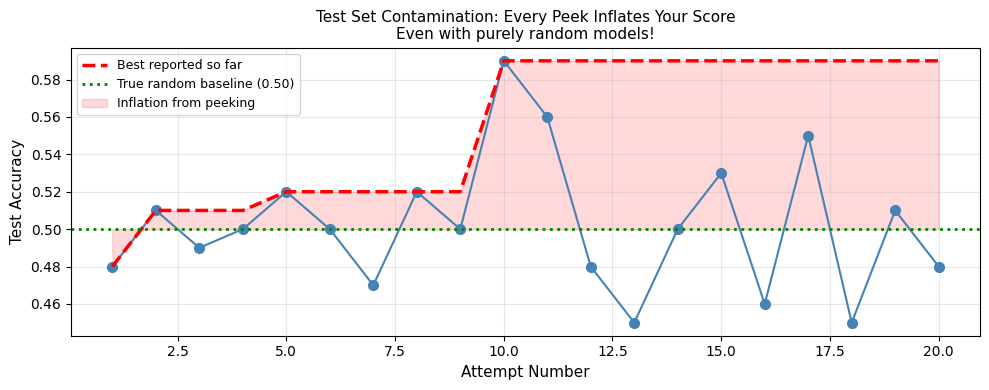

In [8]:
# ── Demonstrate test set contamination ──
print("=" * 55)
print("DEMONSTRATION: How 'peeking' inflates test accuracy")
print("=" * 55)

X, y = make_classification(n_samples=500, n_features=20,
                            n_informative=2, n_redundant=10,
                            random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Simulate a researcher who keeps trying models and
# picking the one with best test score
np.random.seed(0)
test_scores_recorded = []
models_tried = []

print("\nResearcher keeps trying random models, checking test each time:")
print(f"{'Attempt':>8} {'Test Accuracy':>15} {'Note'}")
print("-" * 45)

for attempt in range(1, 21):
    # Each "model" is just random predictions (no real learning!)
    # In reality this represents trying 20 different configs
    random_preds = np.random.randint(0, 2, size=len(y_test))
    acc = accuracy_score(y_test, random_preds)
    test_scores_recorded.append(acc)
    best_so_far = max(test_scores_recorded)
    note = " ← NEW BEST! (reported)" if acc == best_so_far else ""
    print(f"{attempt:>8} {acc:>15.4f}{note}")

print(f"\nTrue random accuracy (should be ~0.50): "
      f"{np.mean(test_scores_recorded):.4f}")
print(f"Best 'reported' accuracy after 20 tries: "
      f"{max(test_scores_recorded):.4f}")
print(f"\n The reported number is INFLATED by selection bias.")
print(f"   This researcher would claim {max(test_scores_recorded):.1%} accuracy")
print(f"   on a model that's actually just random guessing!")

# Visualise
plt.figure(figsize=(10, 4))
plt.plot(range(1,21), test_scores_recorded, 'o-',
         color='steelblue', markersize=7, linewidth=1.5)
plt.plot(range(1,21),
         np.maximum.accumulate(test_scores_recorded),
         'r--', linewidth=2.5, label='Best reported so far')
plt.axhline(0.5, color='green', linestyle=':',
            linewidth=2, label='True random baseline (0.50)')
plt.fill_between(range(1,21),
                 np.maximum.accumulate(test_scores_recorded),
                 0.5, alpha=0.15, color='red',
                 label='Inflation from peeking')
plt.xlabel("Attempt Number", fontsize=11)
plt.ylabel("Test Accuracy", fontsize=11)
plt.title("Test Set Contamination: Every Peek Inflates Your Score\n"
          "Even with purely random models!", fontsize=11)
plt.legend(fontsize=9); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Cross-Validation**

Instead of one train/test split, cross-validation splits the data K times and evaluates the model K times, each time using a different portion as the test set.

The analogy: Rotating exam proctors

Instead of one teacher grading all your work (who might be biased), K different teachers each grade one portion of your work. Your final grade is the average, much fairer and more reliable.

every data point gets to be in the test set exactly once. Nothing is wasted, nothing is peeked at unfairly.

Core Logic — K-Fold Step by Step
```
Data: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  (10 samples, K=5 folds)

Fold 1:  Train=[3,4,5,6,7,8,9,10]  Test=[1,2]   → Score 1
Fold 2:  Train=[1,2,5,6,7,8,9,10]  Test=[3,4]   → Score 2
Fold 3:  Train=[1,2,3,4,7,8,9,10]  Test=[5,6]   → Score 3
Fold 4:  Train=[1,2,3,4,5,6,9,10]  Test=[7,8]   → Score 4
Fold 5:  Train=[1,2,3,4,5,6,7,8]   Test=[9,10]  → Score 5

Final CV Score = mean(Score1...Score5) ± std(Score1...Score5)
The std tells you how STABLE the model is across different data splits
```

K-Fold CV:

Split data into K equal parts. train on K-1, test on 1. Rotate K times.

Stratified K-fold:

Same as K-fold but each fold keeps the same ratio as the full dataset. Always use this for classification.

Leave-One-Out:

K-n, every single point gets its own test run. Very expensive, used only on tiny datasets

CV score ± std:

Mean accuracy across folds ± std.The std tells you how consistent the model is.

Validation Curve:

Plot CV score vs a hyperparameter, shows where model under/overfits

Learning curve

Plot CV score vs training size, shows if you need more data



In [9]:
# ── K-Fold Cross-Validation completely from scratch ──
class KFoldFromScratch:
    """
    K-Fold CV in plain steps.
    See exactly what happens at each fold.
    """
    def __init__(self, n_splits=5, shuffle=True,
                 random_state=42):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state

    def split(self, X):
        """
        Yield (train_indices, test_indices) for each fold.
        This is a generator — yields one fold at a time.
        """
        n = len(X)
        indices = np.arange(n)

        if self.shuffle:
            rng = np.random.RandomState(self.random_state)
            rng.shuffle(indices)

        # Calculate fold sizes
        # e.g. 100 samples, 5 folds → each fold = 20 samples
        fold_sizes = np.full(self.n_splits,
                              n // self.n_splits,
                              dtype=int)
        # Distribute remainder: first few folds get 1 extra sample
        fold_sizes[:n % self.n_splits] += 1

        current = 0
        for fold_size in fold_sizes:
            start, stop = current, current + fold_size
            test_indices  = indices[start:stop]
            train_indices = np.concatenate([indices[:start],
                                             indices[stop:]])
            yield train_indices, test_indices
            current = stop

def cross_validate_scratch(model_class, model_params,
                             X, y, n_splits=5):
    """
    Full cross-validation loop.
    Returns scores and prints fold-by-fold results.
    """
    kf = KFoldFromScratch(n_splits=n_splits)
    scores = []
    scaler = StandardScaler()

    print(f"Running {n_splits}-Fold Cross-Validation:")
    print(f"{'Fold':>6} {'Train Size':>12} "
          f"{'Test Size':>10} {'Accuracy':>10}")
    print("-" * 42)

    for fold_num, (train_idx, test_idx) in enumerate(
            kf.split(X), 1):

        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # Scale inside the fold — CRITICAL to prevent leakage
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        # Train and evaluate
        model = model_class(**model_params)
        model.fit(X_tr_s, y_tr)
        score = accuracy_score(y_te, model.predict(X_te_s))
        scores.append(score)

        print(f"{fold_num:>6} {len(train_idx):>12} "
              f"{len(test_idx):>10} {score:>10.4f}")

    print("-" * 42)
    print(f"{'Mean':>6} {'':>12} {'':>10} {np.mean(scores):>10.4f}")
    print(f"{'Std':>6} {'':>12} {'':>10} {np.std(scores):>10.4f}")
    print(f"\n Final: {np.mean(scores):.4f} ± {np.std(scores):.4f}")
    return np.array(scores)

# Test on breast cancer dataset
data = load_breast_cancer()
X_bc, y_bc = data.data, data.target

print("=" * 42)
print("Logistic Regression:")
print("=" * 42)
lr_scores = cross_validate_scratch(
    LogisticRegression,
    {'max_iter': 1000, 'random_state': 42},
    X_bc, y_bc, n_splits=5)

print("\n" + "=" * 42)
print("Random Forest:")
print("=" * 42)
rf_scores = cross_validate_scratch(
    RandomForestClassifier,
    {'n_estimators': 100, 'random_state': 42},
    X_bc, y_bc, n_splits=5)

Logistic Regression:
Running 5-Fold Cross-Validation:
  Fold   Train Size  Test Size   Accuracy
------------------------------------------
     1          455        114     0.9737
     2          455        114     0.9825
     3          455        114     0.9649
     4          455        114     0.9912
     5          456        113     0.9735
------------------------------------------
  Mean                             0.9771
   Std                             0.0090

 Final: 0.9771 ± 0.0090

Random Forest:
Running 5-Fold Cross-Validation:
  Fold   Train Size  Test Size   Accuracy
------------------------------------------
     1          455        114     0.9649
     2          455        114     0.9649
     3          455        114     0.9561
     4          455        114     0.9649
     5          456        113     0.9646
------------------------------------------
  Mean                             0.9631
   Std                             0.0035

 Final: 0.9631 ± 0.0035


In [10]:
# ── Stratified K-Fold — why class balance matters ──
print("\n" + "=" * 55)
print("WHY STRATIFIED K-FOLD MATTERS")
print("=" * 55)

# Create imbalanced dataset
X_imb, y_imb = make_classification(
    n_samples=1000, n_features=10,
    weights=[0.9, 0.1],  # 90% class 0, 10% class 1
    random_state=42)

print(f"\nDataset class distribution:")
print(f"Class 0: {(y_imb==0).sum()} ({(y_imb==0).mean():.0%})")
print(f"Class 1: {(y_imb==1).sum()} ({(y_imb==1).mean():.0%})")

# Regular K-Fold — class ratio may vary per fold
kf_regular = KFold(n_splits=5, shuffle=True, random_state=42)
kf_strat   = StratifiedKFold(n_splits=5, shuffle=True,
                               random_state=42)

print(f"\n{'Fold':>5} {'Regular KFold':>20} {'Stratified KFold':>20}")
print(f"{'':>5} {'Class1 %':>20} {'Class1 %':>20}")
print("-" * 47)

for fold, ((_, te_reg), (_, te_strat)) in enumerate(
        zip(kf_regular.split(X_imb),
            kf_strat.split(X_imb, y_imb)), 1):
    reg_ratio  = y_imb[te_reg].mean()
    strat_ratio = y_imb[te_strat].mean()
    print(f"{fold:>5} {reg_ratio:>20.1%} {strat_ratio:>20.1%}")

print(f"\n{'True':>5} {(y_imb==1).mean():>20.1%} "
      f"{(y_imb==1).mean():>20.1%}")
print("\n Stratified keeps Class 1 % consistent across folds.")
print("   With imbalanced data, irregular folds = unstable scores.")
print("   ALWAYS use StratifiedKFold for classification.")


WHY STRATIFIED K-FOLD MATTERS

Dataset class distribution:
Class 0: 897 (90%)
Class 1: 103 (10%)

 Fold        Regular KFold     Stratified KFold
                  Class1 %             Class1 %
-----------------------------------------------
    1                12.5%                10.0%
    2                10.0%                10.0%
    3                12.0%                10.5%
    4                 7.0%                10.5%
    5                10.0%                10.5%

 True                10.3%                10.3%

 Stratified keeps Class 1 % consistent across folds.
   With imbalanced data, irregular folds = unstable scores.
   ALWAYS use StratifiedKFold for classification.


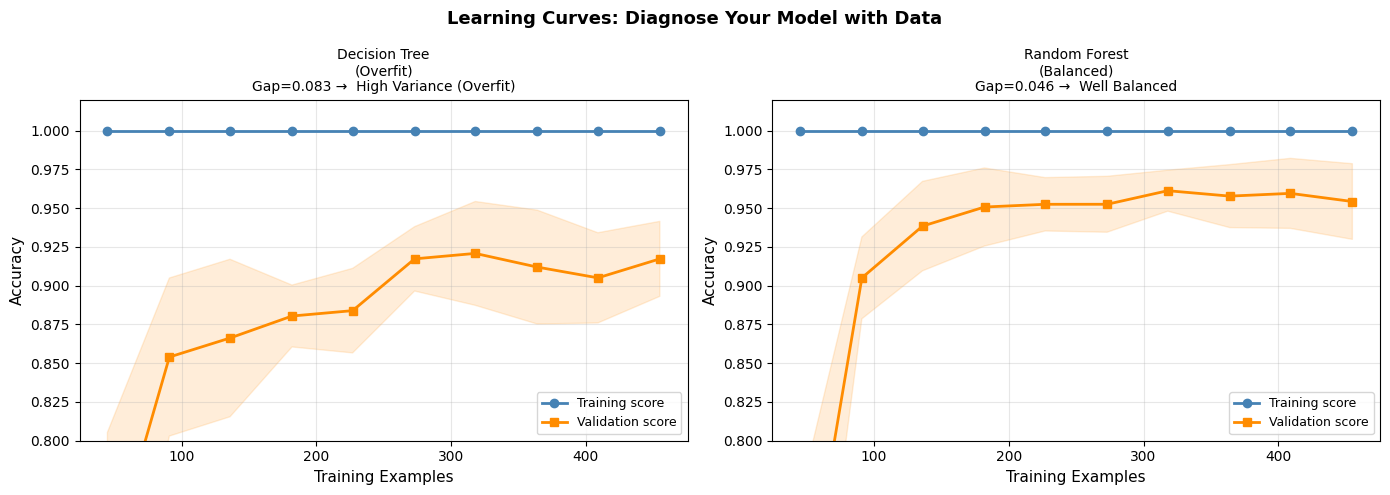


 HOW TO READ LEARNING CURVES:
Large gap between train and val  → High variance (overfit)
Both scores low and close        → High bias (underfit)
Val score still rising at end    → Get more data!
Val score plateaued              → More data won't help


In [11]:
# ── Learning Curves — diagnose with data ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_lc = {
    'Decision Tree\n(Overfit)':
        DecisionTreeClassifier(max_depth=None, random_state=42),
    'Random Forest\n(Balanced)':
        RandomForestClassifier(n_estimators=50, random_state=42)
}

for ax, (name, model) in zip(axes, models_lc.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_bc, y_bc,
        cv=StratifiedKFold(5),
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy', n_jobs=-1)

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-',
            color='steelblue', linewidth=2, label='Training score')
    ax.fill_between(train_sizes,
                    train_mean - train_std,
                    train_mean + train_std,
                    alpha=0.15, color='steelblue')
    ax.plot(train_sizes, val_mean, 's-',
            color='darkorange', linewidth=2,
            label='Validation score')
    ax.fill_between(train_sizes,
                    val_mean - val_std,
                    val_mean + val_std,
                    alpha=0.15, color='darkorange')

    gap = train_mean[-1] - val_mean[-1]
    diagnosis = (" High Variance (Overfit)"
                 if gap > 0.05 else " Well Balanced")
    ax.set_title(f"{name}\nGap={gap:.3f} → {diagnosis}",
                 fontsize=10)
    ax.set_xlabel("Training Examples", fontsize=11)
    ax.set_ylabel("Accuracy", fontsize=11)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.set_ylim(0.8, 1.02)

plt.suptitle("Learning Curves: Diagnose Your Model with Data",
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print("\n HOW TO READ LEARNING CURVES:")
print("Large gap between train and val  → High variance (overfit)")
print("Both scores low and close        → High bias (underfit)")
print("Val score still rising at end    → Get more data!")
print("Val score plateaued              → More data won't help")

**Accuracy is a liar in disguise**

If 99% of emails are not spam and your model says "not spam" for everything, you get 99% accuracy. But you catch 0% of actual spam. the model is useless.

You need n=metrics that reveal what kind of mistakes your model makes. Different problems care about different kind of mistakes.

The confusion matrix is the foundation of everything.

PREDICTED

                  Positive  Negative

        Positive |   TP   |   FN   |

        Negative |   FP   |   TN   |

TP=True positive->correctly predicted positive

TN=True negative->correctly predicted negative

FP=False Positive->predicted positive, actually negative(Type I error)

FN=False Negative->predicted negative, actually positive(Type II error)

Every classification metric is derived from these four numbers.

In [13]:
#The complete metric toolkit with intiition

def explain_all_metrics(y_true, y_pred, y_proba=None, class_name="Positive"):
  """
  Calculate and explain every classification metric.
  All built from the confusion matrix.

  """
  tn, fp, fn, tp=confusion_matrix(y_true, y_pred).ravel()
  print("=" * 60)
  print("The confusion matrix")
  print("=" * 60)
  print(f"True Positives (TP): {tp:4d} -> Correctly caught {class_name}")
  print(f"True Negatives (TN): {tn:4d} -> Correctly caught non-{class_name}")
  print(f"False Positives (FP): {fp:4d} -> False Alarm (said yes, was no)")
  print(f"False Negatives (FN): {fn:4d} -> Missed case (said no, was yes)")

  #Accuracy
  accuracy=(tp + tn) / (tp + tn + fp + fn)
  print(f"\nAccuracy = (TP+TN)/(all) {accuracy:.4f}")
  print(f" -> {accuracy:.1%} of All predictions were correct")
  print(f" Misleading when classes are imbalanced!\n")

  #Precision
  precision = tp / (tp + fp)
  print(f"Precision = TP/(TP+FP) {precision:.4f}")
  print(f"  → Of all cases I flagged as {class_name},")
  print(f"     {precision:.1%} actually were {class_name}")
  print(f"  → High precision = low false alarm rate")
  print(f"  → Use when FP is costly (non-spam email and classify as spam blocking real emails)\n")

  #Recall
  recall=tp / (tp + fn) if (tp + fn) > 0 else 0
  print(f"Recall = TP/(TP+FN) {recall:.4f}")
  print(f"  → Of all ACTUAL {class_name} cases,")
  print(f"     I correctly caught {recall:.1%} of them")
  print(f"  -> High recall=few missed cases")
  print(f"  -> Use when FN is costly(e.g cancer detection(has ncancer and classify as non cancer))\n")

  #F1 Score
  f1 = 2*precision*recall/(precision+recall)\
       if (precision+recall)>0 else 0
  print(f"F1 Score = 2×(P×R)/(P+R) = {f1:.4f}")
  print(f" -> Harmonic mean of precision and recall")
  print(f" ->Harmonic mean punishes extreme values:")
  print(f"    P=1.0, R=0.01 -> F1={2*1*0.01/(1.0*0.01):.3f}(bad!)")
  print(f"     P=0.8, R=0.8  → F1={2*0.8*0.8/(0.8+0.8):.3f} (good!)\n")

  #Specificity
  specificity=tn/(tn+fp) if (tn+fp)>0 else 0
  print(f"Specificity = TN/(TN+FP) {specificity:.4f}")
  print(f"  → Of all ACTUAL non-{class_name} cases,")
  print(f"     I correctly identified {specificity:.1%}")
  print(f"  → Recall for the negative class\n")

  #ROC-AUC
  if y_proba is not None:
    auc=roc_auc_score(y_true, y_proba)
    print(f"ROC-AUC = {auc:.4f}")
    print(f" -> Probability that model ranks a random positive")
    print(f"     higher than a random negative")
    print(f" ->0.5=random, 1.0=perfect")
    print(f"  → Threshold-independent → great for comparison\n")

  #PR-AUC
  if y_proba is not None:
    ap=average_precision_score(y_true, y_proba)
    print(f"PR-AUC (Avg Precision) = {ap:.4f}")
    print(f"  → Area under Precision-Recall curve")
    print(f"  → Better than ROC-AUC for imbalanced data")
    print(f"  → Focuses only on positive class performance\n")

  print("=" * 60)
  print("Which metric to use when:")
  print(" Balanced classes, equal costs  -> Accuracy or F1")
  print(" Imbalanced classes             -> F1, PR-AUC")
  print(" FP costly (spam, false arrests)-> Precision")
  print(" FN costly (cancer, fraud miss) -> Recall")
  print(" Ranking/Threshold-free compare -> ROC-AUC")
  print(" Severe imbalance + ranking     -> PR-AUC")

#Load and prepare data
data = load_breast_cancer()
X_bc, y_bc=data.data, data.target
X_tr, X_te, y_tr, y_te=train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42,
    stratify=y_bc
)

scaler_bc=StandardScaler()
X_tr_s=scaler_bc.fit_transform(X_tr)
X_te_s=scaler_bc.transform(X_te)

model=LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_tr)
y_pred = model.predict( X_te_s)
y_proba = model.predict_proba(X_te_s)[:, 1]

explain_all_metrics(y_te, y_pred, y_proba, class_name="malignant")



The confusion matrix
True Positives (TP):   71 -> Correctly caught malignant
True Negatives (TN):   41 -> Correctly caught non-malignant
False Positives (FP):    1 -> False Alarm (said yes, was no)
False Negatives (FN):    1 -> Missed case (said no, was yes)

Accuracy = (TP+TN)/(all) 0.9825
 -> 98.2% of All predictions were correct
 Misleading when classes are imbalanced!

Precision = TP/(TP+FP) 0.9861
  → Of all cases I flagged as malignant,
     98.6% actually were malignant
  → High precision = low false alarm rate
  → Use when FP is costly (e.g., spam filter)

Recall = TP/(TP+FN) 0.9861
  → Of all ACTUAL malignant cases,
     I correctly caught 98.6% of them
  -> High recall=few missed cases
  -> Use when FN is costly(e.g cancer detection)

F1 Score = 2×(P×R)/(P+R) = 0.9861
 -> Harmonic mean of precision and recall
 ->Harmonic mean punishes extreme values:
    P=1.0, R=0.01 -> F1=2.000(bad!)
     P=0.8, R=0.8  → F1=0.800 (good!)

Specificity = TN/(TN+FP) 0.9762
  → Of all ACTUAL no

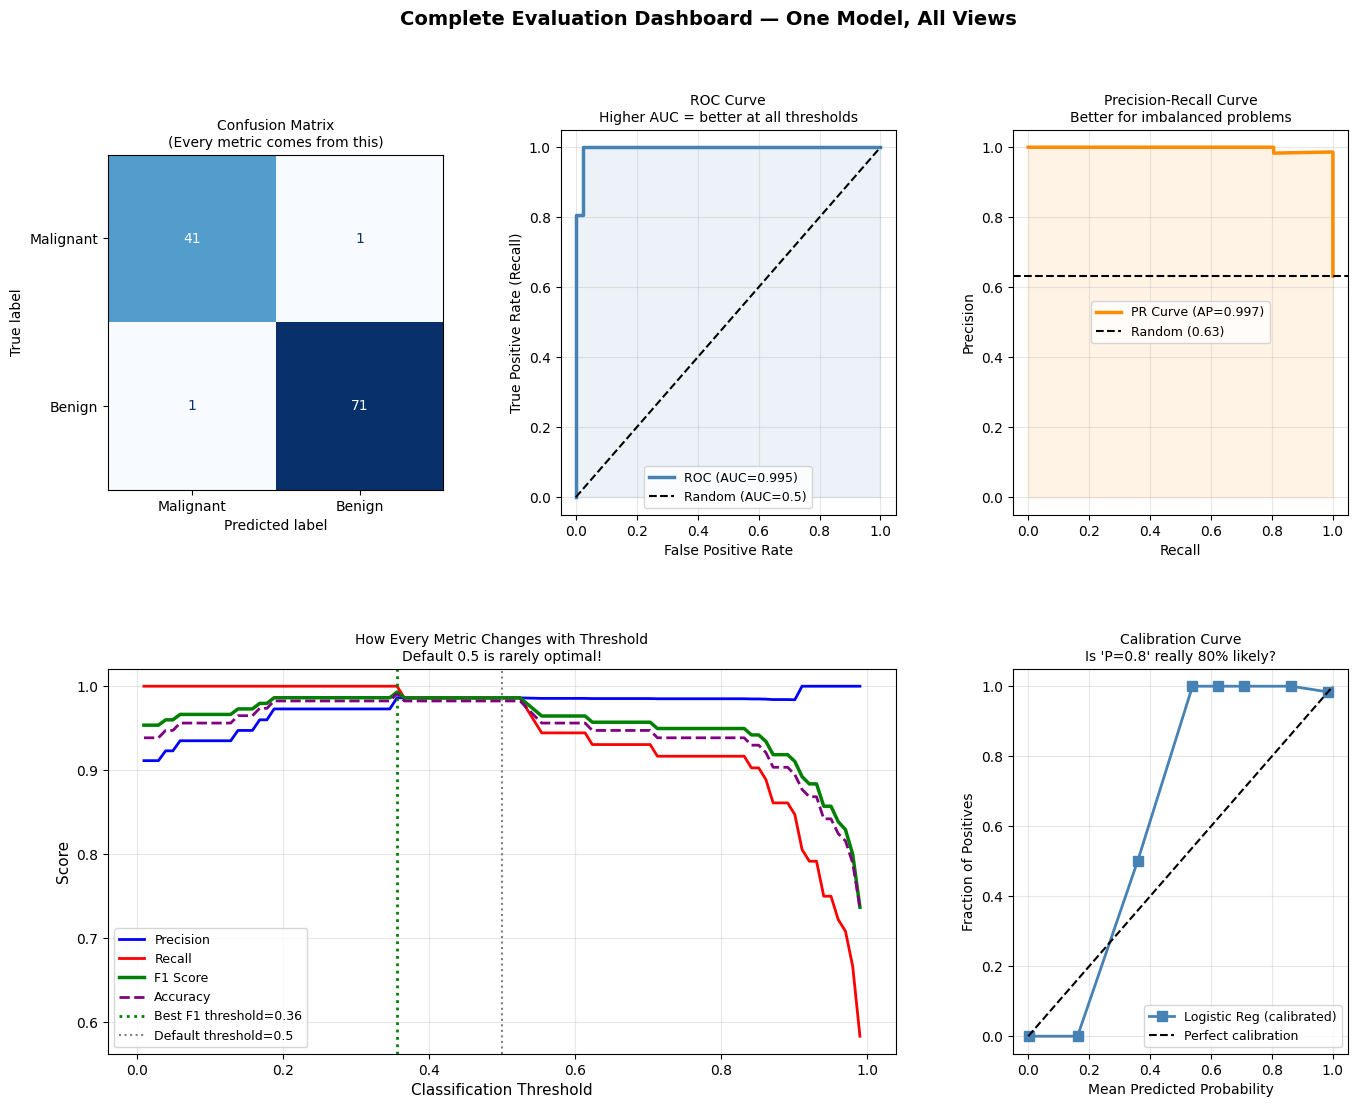


🔑 KEY INSIGHT FROM CALIBRATION CURVE:
A well-calibrated model: when it says 80% probability,
the event happens 80% of the time in reality.
Logistic Regression is naturally well-calibrated.
Tree-based models often need post-hoc calibration (Platt scaling).


In [14]:
# ── Visualise ALL metrics together ──
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── 1. Confusion Matrix ──
ax1 = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Malignant', 'Benign'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title("Confusion Matrix\n"
              "(Every metric comes from this)", fontsize=10)

# ── 2. ROC Curve ──
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, thresholds_roc = roc_curve(y_te, y_proba)
auc = roc_auc_score(y_te, y_proba)
ax2.plot(fpr, tpr, color='steelblue', linewidth=2.5,
         label=f'ROC (AUC={auc:.3f})')
ax2.plot([0,1],[0,1],'k--', linewidth=1.5,
         label='Random (AUC=0.5)')
ax2.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax2.set_xlabel("False Positive Rate", fontsize=10)
ax2.set_ylabel("True Positive Rate (Recall)", fontsize=10)
ax2.set_title("ROC Curve\n"
              "Higher AUC = better at all thresholds", fontsize=10)
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

# ── 3. Precision-Recall Curve ──
ax3 = fig.add_subplot(gs[0, 2])
precision_curve, recall_curve, thresholds_pr = \
    precision_recall_curve(y_te, y_proba)
ap = average_precision_score(y_te, y_proba)
ax3.plot(recall_curve, precision_curve,
         color='darkorange', linewidth=2.5,
         label=f'PR Curve (AP={ap:.3f})')
ax3.axhline(y_te.mean(), color='k', linestyle='--',
            label=f'Random ({y_te.mean():.2f})')
ax3.fill_between(recall_curve, precision_curve,
                  alpha=0.1, color='darkorange')
ax3.set_xlabel("Recall", fontsize=10)
ax3.set_ylabel("Precision", fontsize=10)
ax3.set_title("Precision-Recall Curve\n"
              "Better for imbalanced problems", fontsize=10)
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

# ── 4. Threshold vs Metrics ──
ax4 = fig.add_subplot(gs[1, 0:2])
thresholds_arr = np.linspace(0.01, 0.99, 100)
p_arr, r_arr, f1_arr, acc_arr = [], [], [], []

for thresh in thresholds_arr:
    y_t = (y_proba >= thresh).astype(int)
    p_arr.append(precision_score(y_te, y_t, zero_division=0))
    r_arr.append(recall_score(y_te, y_t, zero_division=0))
    f1_arr.append(f1_score(y_te, y_t, zero_division=0))
    acc_arr.append(accuracy_score(y_te, y_t))

ax4.plot(thresholds_arr, p_arr, color='blue',
         linewidth=2, label='Precision')
ax4.plot(thresholds_arr, r_arr, color='red',
         linewidth=2, label='Recall')
ax4.plot(thresholds_arr, f1_arr, color='green',
         linewidth=2.5, label='F1 Score')
ax4.plot(thresholds_arr, acc_arr, color='purple',
         linewidth=2, linestyle='--', label='Accuracy')
best_f1_thresh = thresholds_arr[np.argmax(f1_arr)]
ax4.axvline(best_f1_thresh, color='green',
            linestyle=':', linewidth=2,
            label=f'Best F1 threshold={best_f1_thresh:.2f}')
ax4.axvline(0.5, color='gray', linestyle=':',
            linewidth=1.5, label='Default threshold=0.5')
ax4.set_xlabel("Classification Threshold", fontsize=11)
ax4.set_ylabel("Score", fontsize=11)
ax4.set_title("How Every Metric Changes with Threshold\n"
              "Default 0.5 is rarely optimal!", fontsize=10)
ax4.legend(fontsize=9); ax4.grid(alpha=0.3)

# ── 5. Calibration Curve ──
ax5 = fig.add_subplot(gs[1, 2])
fraction_pos, mean_pred = calibration_curve(
    y_te, y_proba, n_bins=10)
ax5.plot(mean_pred, fraction_pos, 's-',
         color='steelblue', linewidth=2,
         markersize=7, label='Logistic Reg (calibrated)')
ax5.plot([0,1],[0,1],'k--', linewidth=1.5,
         label='Perfect calibration')
ax5.fill_between([0,1],[0,1],[0,1],
                  alpha=0.05, color='green')
ax5.set_xlabel("Mean Predicted Probability", fontsize=10)
ax5.set_ylabel("Fraction of Positives", fontsize=10)
ax5.set_title("Calibration Curve\n"
              "Is 'P=0.8' really 80% likely?", fontsize=10)
ax5.legend(fontsize=9); ax5.grid(alpha=0.3)

plt.suptitle("Complete Evaluation Dashboard — One Model, All Views",
             fontsize=14, fontweight='bold')
plt.show()

print("\n🔑 KEY INSIGHT FROM CALIBRATION CURVE:")
print("A well-calibrated model: when it says 80% probability,")
print("the event happens 80% of the time in reality.")
print("Logistic Regression is naturally well-calibrated.")
print("Tree-based models often need post-hoc calibration (Platt scaling).")

**The End to End ML Pipeline**

* Reproducible(same result every time)
* Leak-free(no test data pollutes training)
* Comparable (fair model comparision)
* Deployable(can be used on new data)

sklearn's pipeline objcet does this. It chains preprocessing and modeling into one object that habdles everything correctly and automatically.

The analogy-an assembly line: Instead of manually passing data through ach step and hoping you do it the same way every time, you build a conveyor belt. Raw data goes in one end, prediction comes out the other. Every step is guaranted to happen in the right order, the right way, every time.

BUILDING ML PIPELINE
------------------------------------------------------------

Dataset shape: (800, 15)
Missing values: 985(8.2% of all values)

Model                    CV ACC   ±   CV AUC   Test Acc   Test AUC    Time
----------------------------------------------------------------------
Logistic regression      0.7828 0.057   0.8506     0.7375     0.8054    1.1s
Random Forest            0.8781 0.043   0.9536     0.8625     0.9337    6.0s
Gradient Boosting        0.8594 0.034   0.9426     0.8625     0.9245   11.6s
SVM                      0.8953 0.036   0.9612     0.8938     0.9523    1.2s


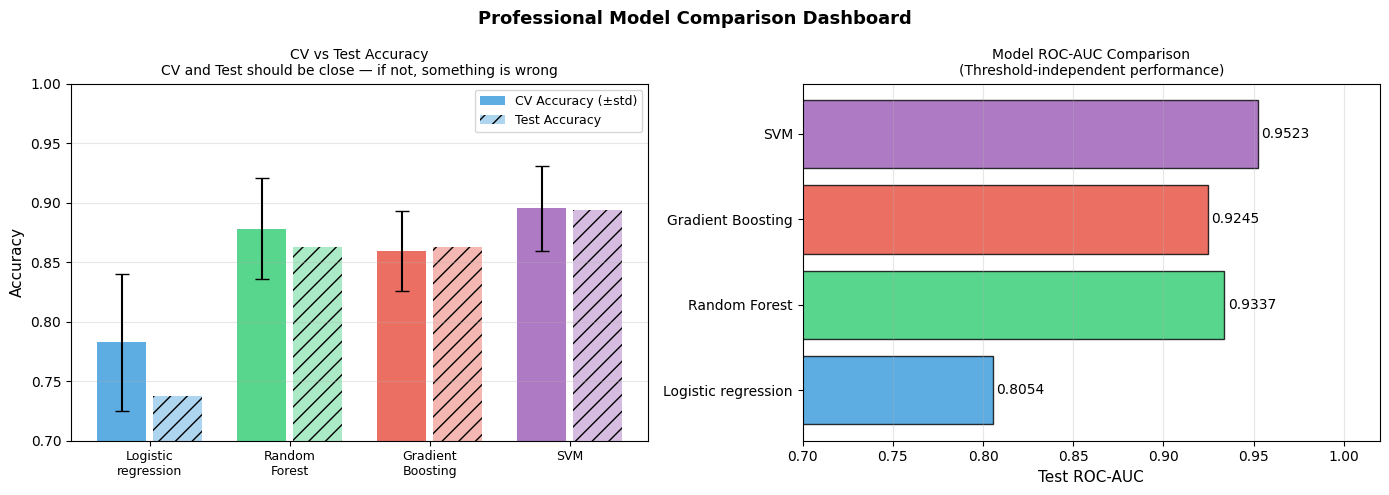


🏆 Best model: SVM

Full classification report:
              precision    recall  f1-score   support

     Class 0       0.90      0.89      0.89        81
     Class 1       0.89      0.90      0.89        79

    accuracy                           0.89       160
   macro avg       0.89      0.89      0.89       160
weighted avg       0.89      0.89      0.89       160



In [4]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
import time

print("BUILDING ML PIPELINE")
print("-" * 60)

#Step1: Create a realistic messy dataset
# real data is always messy
np.random.seed(42)
X_raw, y_raw=make_classification(
    n_samples=800, n_features=15,
    n_informative=8, n_redundant=4,
    random_state=42
)

#Introduce messiness: missing values
X_messy=X_raw.copy().astype(float)
missing_mask=np.random.random(X_messy.shape)<0.08 #8% missing
X_messy[missing_mask]=np.nan

print(f"\nDataset shape: {X_messy.shape}")
print(f"Missing values: {np.isnan(X_messy).sum()}"
      f"({np.isnan(X_messy).mean():.1%} of all values)")

X_tr_raw, X_te_raw, y_tr_raw, y_te_raw=train_test_split(
    X_messy, y_raw,
    test_size=0.2, random_state=42,
    stratify=y_raw #The stratify parameter in scikit-learn's train_test_split function ensures that the resulting training and testing subsets maintain the same proportion of class labels as the original dataset.
)

# Step 2: Define pipelines for multiple models
pipelines={
    'Logistic regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42)) #max_iter=1000, how many times the algorithm is allowed to try to find the best solution.

    ]),
    'Random Forest':Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42)) # n_estimators=100, how many trees to build
    ]),
    'Gradient Boosting':Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', GradientBoostingClassifier(n_estimators=100, random_state=42)) #n_estimators=100, how many correction step(trees) to run sequentially
    ]),
    'SVM':Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', SVC(probability=True,random_state=42)) #probability=True, by default SVM only says"class 0 or 1" this flag forces it to also output a confidence score (like 0.87) which is needed to calculate AUC. without this, predict_proba() would crash.
    ]),
}

#Step3: Fair Comparision using the SAME cross-validation splits
cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"\n{'Model':<22} {'CV ACC':>8}{'±':>4} "
      f"{'CV AUC':>8} {'Test Acc':>10} {'Test AUC':>10} {'Time':>7}")

print('-'*70)

results = {}
for name, pipeline in pipelines.items():
  start=time.time()

  #CV on training data only
  cv_scores = cross_val_score(
        pipeline, X_tr_raw, y_tr_raw,
        cv=cv, scoring='accuracy')
  cv_auc = cross_val_score(
        pipeline, X_tr_raw, y_tr_raw,
        cv=cv, scoring='roc_auc')

  #Evaluation on untouched test set
  pipeline.fit(X_tr_raw, y_tr_raw)
  y_pred_final  = pipeline.predict(X_te_raw)
  y_proba_final = pipeline.predict_proba(X_te_raw)[:, 1]
  test_acc = accuracy_score(y_te_raw, y_pred_final)
  test_auc = roc_auc_score(y_te_raw, y_proba_final)
  elapsed  = time.time() - start

  results[name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std':  cv_scores.std(),
        'cv_auc':  cv_auc.mean(),
        'test_acc': test_acc,
        'test_auc': test_auc
    }
  print(f"{name:<22} {cv_scores.mean():>8.4f} "
          f"{cv_scores.std():>4.3f} "
          f"{cv_auc.mean():>8.4f} "
          f"{test_acc:>10.4f} "
          f"{test_auc:>10.4f} "
          f"{elapsed:>6.1f}s")

# Step 4: Visualise model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names  = list(results.keys())
cv_means  = [results[m]['cv_mean']  for m in model_names]
cv_stds   = [results[m]['cv_std']   for m in model_names]
test_accs = [results[m]['test_acc'] for m in model_names]
test_aucs = [results[m]['test_auc'] for m in model_names]

colors_bar = ['#3498DB','#2ECC71','#E74C3C','#9B59B6']
x_pos = np.arange(len(model_names))

# CV vs Test accuracy
ax = axes[0]
bars1 = ax.bar(x_pos - 0.2, cv_means,  0.35,
               yerr=cv_stds, capsize=5,
               color=colors_bar, alpha=0.8,
               label='CV Accuracy (±std)')
bars2 = ax.bar(x_pos + 0.2, test_accs, 0.35,
               color=colors_bar, alpha=0.4,
               hatch='//', label='Test Accuracy')
ax.set_xticks(x_pos)
ax.set_xticklabels([n.replace(' ', '\n')
                     for n in model_names], fontsize=9)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_title("CV vs Test Accuracy\n"
             "CV and Test should be close — if not, something is wrong",
             fontsize=10)
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')
ax.set_ylim(0.7, 1.0)

# AUC comparison
ax2 = axes[1]
ax2.barh(model_names, test_aucs,
         color=colors_bar, alpha=0.8,
         edgecolor='black')
for i, auc in enumerate(test_aucs):
    ax2.text(auc + 0.002, i, f'{auc:.4f}',
             va='center', fontsize=10)
ax2.set_xlabel("Test ROC-AUC", fontsize=11)
ax2.set_title("Model ROC-AUC Comparison\n"
              "(Threshold-independent performance)", fontsize=10)
ax2.set_xlim(0.7, 1.02)
ax2.grid(alpha=0.3, axis='x')

plt.suptitle("Professional Model Comparison Dashboard",
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Step 5: Show the best model's full report
best_model_name = max(results,
                       key=lambda x: results[x]['test_auc'])
best_pipeline   = pipelines[best_model_name]
y_pred_best     = best_pipeline.predict(X_te_raw)

print(f"\n🏆 Best model: {best_model_name}")
print(f"\nFull classification report:")
print(classification_report(y_te_raw, y_pred_best,
                             target_names=['Class 0','Class 1']))

Step 1: Make messy data Real.

Real data has missing values. So they create clean data and then randomly punch holes in it (8% of values become NaN). This is just to simulate reality.

Step 2: Pipeline

A pipeline chains steps so they always run in order: impute(fillna)->scale->model. The genius of it: when you call pupeline.fit(), all three steps happen automatically. When you call pipeline.predict(), it auto-applies the same transformations. You can't accidently forget to scale the test data.

Step 3: CV on training data only

cross_val_score runs 5-fold CV but only touches X_tr_raw. The test set X_te_raw is locked in a vault. This gives you an honest estimate how each model performs.

Step 4: Final test

After CV, each pipeline gets trained on the full training set and evaluated once on the locked test set. This is real-world score.

Step 5: Pick the winner

max(results, key=lambda x: results[x] ['text_auc]) just means: loop through all models, return the one with the highest AUC.

In [6]:
#make messy data
X, y = make_classification(
    n_samples=500, n_features=15, random_state=42
)

X_messy= X.copy().astype(float)
missing_mask=np.random.random(X_messy.shape)<0.05
X_messy[missing_mask]=np.nan

X_train, X_test, y_train, y_test=train_test_split(
    X_messy, y, test_size=0.2, random_state=42, stratify=y
)

pipelines={
    'SVM':Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', SVC(probability=True, random_state=42))
    ]),
}

cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, pipeline in pipelines.items():
  start=time.time()

  cv_scores=cross_val_score(
      pipeline, X_train, y_train, cv=cv, scoring='accuracy'
  )
  cv_auc=cross_val_score(
      pipeline, X_train, y_train, cv=cv, scoring='roc_auc'
  )

  pipeline.fit(X_train, y_train)
  y_pred=pipeline.predict(X_test)
  y_probab=pipeline.predict_proba(X_test)[:, 1] # Corrected to use X_test for test probabilities
  test_acc=accuracy_score(y_test, y_pred) # Corrected typo
  test_auc=roc_auc_score(y_test, y_probab)
  elapsed=time.time()-start

  results[name]={
      'cv_mean': cv_scores.mean(),
      'cv_std': cv_scores.std(),
      'cv_auc': cv_auc.mean(),
      'test_acc': test_acc,
      'test_auc': test_auc
  }
  print(f"{name:<22} {cv_scores.mean():>8.4f} "
          f"{cv_scores.std():>4.3f} "
          f"{cv_auc.mean():>8.4f} "
          f"{test_acc:>10.4f} "
          f"{test_auc:>10.4f} ")


SVM                      0.8150 0.044   0.9033     0.9100     0.9712 


pipeline.fit(X_train, y_train)
pipeline.predict(X_test)
```

Answer:
```
fit():
  Step 1 → Imputer.fit(X_train) → learns median of each feature from training data
          Imputer.transform(X_train) → fills missing values using training medians
  Step 2 → Scaler.fit(X_train_imputed) → learns mean/std from training data
          Scaler.transform(X_train_imputed) → scales using training stats
  Step 3 → Model.fit(X_train_scaled, y_train) → trains on clean, scaled data

predict():
  Step 1 → Imputer.transform(X_test) → fills using TRAINING medians (not test!)
  Step 2 → Scaler.transform(X_test)  → scales using TRAINING stats (not test!)
  Step 3 → Model.predict(X_test_scaled) → generates predictions

The test set NEVER influences any fitted parameters. Zero leakage.